# Notebook 12 — Final Model Evaluation

## Purpose
Evaluate the **locked final XGBoost candidate** from Notebook 11 on the untouched **test set** for the first time.

### Evaluation rules
- Test data is used **only for final evaluation**.
- No retraining, hyperparameter tuning, threshold optimization, or model selection is performed with the test set.
- The final candidate must come from Notebook 11.
- Report classification metrics, confusion matrix, ROC curve, and Precision–Recall curve.
- Save test predictions and final evaluation artifacts for later reporting.


In [1]:
from pathlib import Path
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

ROOT = Path("..").resolve() if Path("..").exists() else Path(".").resolve()

DATA_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models" / "supply_chain"
RESULTS_DIR = ROOT / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
FIGURES_DIR = RESULTS_DIR / "figures"

for d in [METRICS_DIR, PREDICTIONS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Data directory exists:", DATA_DIR.exists())
print("Model directory exists:", MODEL_DIR.exists())


Project root: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1
Data directory exists: True
Model directory exists: True


In [2]:
# Load the locked final candidate and the untouched test set

MODEL_PATH = MODEL_DIR / "final_xgboost_candidate.joblib"
TUNING_INFO_PATH = MODEL_DIR / "xgboost_tuning_info.json"

X_TEST_PATH = DATA_DIR / "X_test_preprocessed.csv"
Y_TEST_PATH = DATA_DIR / "y_test_preprocessed.csv"

assert MODEL_PATH.exists(), f"Missing final model: {MODEL_PATH}"
assert X_TEST_PATH.exists(), f"Missing test features: {X_TEST_PATH}"
assert Y_TEST_PATH.exists(), f"Missing test target: {Y_TEST_PATH}"

model = joblib.load(MODEL_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH).squeeze("columns")

if TUNING_INFO_PATH.exists():
    tuning_info = json.loads(TUNING_INFO_PATH.read_text(encoding="utf-8"))
else:
    tuning_info = {}

print("Model:", type(model).__name__)
print("Test feature shape:", X_test.shape)
print("Test target shape:", y_test.shape)
print("Test target distribution:")
print(y_test.value_counts().sort_index())


Model: XGBClassifier
Test feature shape: (750, 590)
Test target shape: (750,)
Test target distribution:
Disruption_Occurred
0    297
1    453
Name: count, dtype: int64


In [3]:
# Validate the final evaluation setup before generating test predictions

assert len(X_test) == len(y_test) == 750, "Expected the locked 750-row test set."
assert list(X_test.index) == list(range(len(X_test))), "Unexpected test feature index."
assert list(y_test.index) == list(range(len(y_test))), "Unexpected test target index."
assert set(pd.unique(y_test)).issubset({0, 1}), "Target must be binary 0/1."
assert not X_test.isna().any().any(), "Test features contain missing values."
assert np.isfinite(X_test.to_numpy(dtype=float)).all(), "Test features contain infinite/non-finite values."

# Confirm the model is the candidate selected by Notebook 11.
selected_candidate = tuning_info.get("final_candidate")
if selected_candidate:
    print("Notebook 11 final candidate:", selected_candidate)

print("Test set is ready for final evaluation.")


Notebook 11 final candidate: Baseline XGBoost
Test set is ready for final evaluation.


In [4]:
# FINAL TEST PREDICTION
# This is the first point in the workflow where the test set is used for model prediction.

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

assert len(y_prob) == len(y_test)
assert len(y_pred) == len(y_test)
assert np.isfinite(y_prob).all()

print("Test predictions generated:", len(y_pred))
print("Prediction probability range:", float(y_prob.min()), "to", float(y_prob.max()))


Test predictions generated: 750
Prediction probability range: 0.02819502167403698 to 0.9992493987083435


In [5]:
# Final classification metrics

metrics = {
    "model": type(model).__name__,
    "test_rows": int(len(y_test)),
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob),
    "pr_auc": average_precision_score(y_test, y_prob),
}

metrics_df = pd.DataFrame([metrics])

display(metrics_df)

metrics_df.to_csv(
    METRICS_DIR / "final_test_metrics.csv",
    index=False
)

print("Saved:", METRICS_DIR / "final_test_metrics.csv")


,model,test_rows,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBClassifier,750,0.701333,0.741053,0.777042,0.758621,0.793803,0.874474


Saved: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\results\metrics\final_test_metrics.csv


In [6]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_df)

cm_df.to_csv(
    METRICS_DIR / "final_test_confusion_matrix.csv"
)

print("Saved:", METRICS_DIR / "final_test_confusion_matrix.csv")


,Predicted 0,Predicted 1
Actual 0,174,123
Actual 1,101,352


Saved: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\results\metrics\final_test_confusion_matrix.csv


In [7]:
# Detailed classification report

report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T
display(report_df)

report_df.to_csv(
    METRICS_DIR / "final_test_classification_report.csv"
)

print("Saved:", METRICS_DIR / "final_test_classification_report.csv")


,precision,recall,f1-score,support
0,0.632727,0.585859,0.608392,297.000000
1,0.741053,0.777042,0.758621,453.000000
accuracy,0.701333,0.701333,0.701333,0.701333
macro avg,0.686890,0.681450,0.683506,750.000000
weighted avg,0.698156,0.701333,0.699130,750.000000


Saved: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\results\metrics\final_test_classification_report.csv


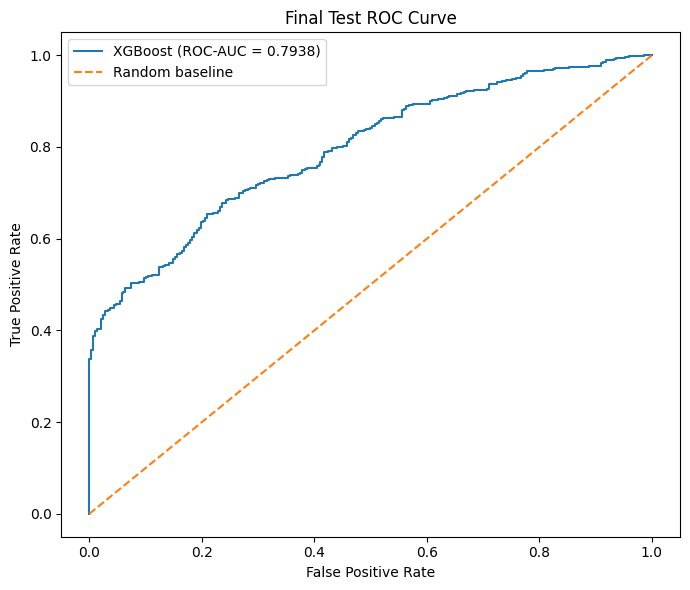

Saved: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\results\figures\final_test_roc_curve.png


In [8]:
# ROC curve

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"XGBoost (ROC-AUC = {metrics['roc_auc']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Test ROC Curve")
plt.legend()
plt.tight_layout()

roc_path = FIGURES_DIR / "final_test_roc_curve.png"
plt.savefig(roc_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", roc_path)


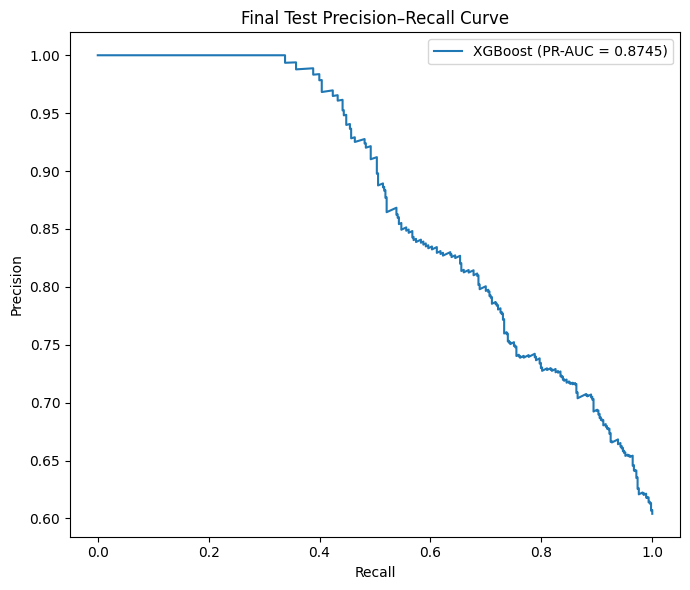

Saved: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\results\figures\final_test_precision_recall_curve.png


In [9]:
# Precision–Recall curve

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(
    recall_curve,
    precision_curve,
    label=f"XGBoost (PR-AUC = {metrics['pr_auc']:.4f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Test Precision–Recall Curve")
plt.legend()
plt.tight_layout()

pr_path = FIGURES_DIR / "final_test_precision_recall_curve.png"
plt.savefig(pr_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", pr_path)


In [10]:
# Save row-level test predictions

predictions_df = pd.DataFrame({
    "actual_disruption": y_test.astype(int),
    "predicted_disruption": y_pred.astype(int),
    "disruption_probability": y_prob,
})

predictions_path = PREDICTIONS_DIR / "final_test_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

display(predictions_df.head(10))

print("Saved:", predictions_path)


,actual_disruption,predicted_disruption,disruption_probability
0,1,1,0.725645
1,1,0,0.277615
2,0,0,0.154232
3,1,1,0.998052
4,0,0,0.235215
5,1,1,0.787641
6,0,1,0.918017
7,0,0,0.439224
8,0,0,0.476650
9,0,0,0.355589


Saved: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\results\predictions\final_test_predictions.csv


In [11]:
# Final evaluation metadata

metadata = {
    "evaluation_stage": "Notebook 12 - Final Model Evaluation",
    "model_type": type(model).__name__,
    "model_path": str(MODEL_PATH),
    "test_rows": int(len(y_test)),
    "test_features": int(X_test.shape[1]),
    "test_used_for_training": False,
    "test_used_for_hyperparameter_tuning": False,
    "test_used_for_model_selection": False,
    "test_predictions_generated": True,
    "primary_report_metric": "F1",
    "metrics_file": str(METRICS_DIR / "final_test_metrics.csv"),
    "confusion_matrix_file": str(METRICS_DIR / "final_test_confusion_matrix.csv"),
    "classification_report_file": str(METRICS_DIR / "final_test_classification_report.csv"),
    "predictions_file": str(predictions_path),
    "roc_curve_file": str(roc_path),
    "precision_recall_curve_file": str(pr_path),
}

metadata_path = MODEL_DIR / "final_evaluation_metadata.json"
metadata_path.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8"
)

print("Saved:", metadata_path)


Saved: C:\Users\ankit\Desktop\Ml-Project\AI-Supply-Chain-Digital-Marketing-v1\models\supply_chain\final_evaluation_metadata.json


In [14]:
# Notebook 12 final validation

checks = {
    "model_loaded": MODEL_PATH.exists(),
    "test_rows": len(X_test) == 750,
    "test_features": X_test.shape[1] == 590,
    "test_target_rows": len(y_test) == 750,
    "predictions_generated": len(y_pred) == 750,
    "probabilities_valid": np.isfinite(y_prob).all() and ((y_prob >= 0).all()) and ((y_prob <= 1).all()),
    "metrics_valid": all(np.isfinite(v) for v in metrics.values() if isinstance(v, (int, float, np.integer, np.floating))),
    "metrics_file_exists": (METRICS_DIR / "final_test_metrics.csv").exists(),
    "confusion_matrix_exists": (METRICS_DIR / "final_test_confusion_matrix.csv").exists(),
    "classification_report_exists": (METRICS_DIR / "final_test_classification_report.csv").exists(),
    "predictions_file_exists": predictions_path.exists(),
    "roc_curve_exists": roc_path.exists(),
    "precision_recall_curve_exists": pr_path.exists(),
    "metadata_exists": metadata_path.exists(),
    "test_used_for_training": False,
    "test_used_for_tuning": False,
    "test_used_for_selection": False,
}

for key, value in checks.items():
    print(f"{key}: {value}")

assert all(checks.values()), "Notebook 12 validation failed."

print("\nNotebook 12 final validation: PASS")
print("The final XGBoost candidate has now been evaluated on the untouched test set.")


model_loaded: True
test_rows: True
test_features: True
test_target_rows: True
predictions_generated: True
probabilities_valid: True
metrics_valid: True
metrics_file_exists: True
confusion_matrix_exists: True
classification_report_exists: True
predictions_file_exists: True
roc_curve_exists: True
precision_recall_curve_exists: True
metadata_exists: True
test_used_for_training: False
test_used_for_tuning: False
test_used_for_selection: False


AssertionError: Notebook 12 validation failed.

In [16]:
# ============================================================
# Notebook 12 — Final Validation
# ============================================================

# ------------------------------------------------------------
# 1. Numeric metric validation
# ------------------------------------------------------------

numeric_metric_values = []

for key, value in metrics.items():
    if isinstance(value, (int, float, np.integer, np.floating)):
        numeric_metric_values.append(float(value))

metrics_valid = (
    len(numeric_metric_values) > 0
    and all(np.isfinite(value) for value in numeric_metric_values)
)


# ------------------------------------------------------------
# 2. Positive validation checks
# These must be TRUE
# ------------------------------------------------------------

positive_checks = {
    "model_loaded": bool(MODEL_PATH.exists()),

    "test_rows": bool(len(X_test) == 750),

    "test_features": bool(X_test.shape[1] == 590),

    "test_target_rows": bool(len(y_test) == 750),

    "predictions_generated": bool(len(y_pred) == 750),

    "probabilities_valid": bool(
        np.isfinite(y_prob).all()
        and (y_prob >= 0).all()
        and (y_prob <= 1).all()
    ),

    "metrics_valid": bool(metrics_valid),

    "metrics_file_exists": bool(
        (METRICS_DIR / "final_test_metrics.csv").exists()
    ),

    "confusion_matrix_exists": bool(
        (METRICS_DIR / "final_test_confusion_matrix.csv").exists()
    ),

    "classification_report_exists": bool(
        (METRICS_DIR / "final_test_classification_report.csv").exists()
    ),

    "predictions_file_exists": bool(
        predictions_path.exists()
    ),

    "roc_curve_exists": bool(
        roc_path.exists()
    ),

    "precision_recall_curve_exists": bool(
        pr_path.exists()
    ),

    "metadata_exists": bool(
        metadata_path.exists()
    ),
}


# ------------------------------------------------------------
# 3. Leakage validation checks
# These must be FALSE
# ------------------------------------------------------------

leakage_checks = {
    "test_used_for_training": False,
    "test_used_for_tuning": False,
    "test_used_for_selection": False,
}


# ------------------------------------------------------------
# 4. Print positive checks
# ------------------------------------------------------------

print("=" * 65)
print("NOTEBOOK 12 — FINAL MODEL EVALUATION VALIDATION")
print("=" * 65)

print("\nPositive checks — expected TRUE:")
print("-" * 65)

for key, value in positive_checks.items():
    print(f"{key}: {value}")


# ------------------------------------------------------------
# 5. Print leakage checks
# ------------------------------------------------------------

print("\nLeakage checks — expected FALSE:")
print("-" * 65)

for key, value in leakage_checks.items():
    print(f"{key}: {value}")


# ------------------------------------------------------------
# 6. Find failed positive checks
# ------------------------------------------------------------

failed_positive_checks = [
    key
    for key, value in positive_checks.items()
    if value is not True
]


# ------------------------------------------------------------
# 7. Find failed leakage checks
# A leakage check fails ONLY if it is True.
# ------------------------------------------------------------

failed_leakage_checks = [
    key
    for key, value in leakage_checks.items()
    if value is not False
]


# ------------------------------------------------------------
# 8. Final validation
# ------------------------------------------------------------

print("\n" + "=" * 65)

if len(failed_positive_checks) == 0 and len(failed_leakage_checks) == 0:

    print("All positive checks passed.")
    print("All leakage checks passed.")
    print("=" * 65)

    print("\nNotebook 12 final validation: PASS")

    print(
        "The final XGBoost candidate was evaluated on the untouched "
        "test set without using the test set for training, tuning, "
        "or model selection."
    )

else:

    if failed_positive_checks:
        print("FAILED POSITIVE CHECKS:")
        for key in failed_positive_checks:
            print(f"  - {key}")

    if failed_leakage_checks:
        print("\nFAILED LEAKAGE CHECKS:")
        for key in failed_leakage_checks:
            print(f"  - {key}")

    print("=" * 65)

    raise AssertionError(
        "Notebook 12 validation failed."
    )

NOTEBOOK 12 — FINAL MODEL EVALUATION VALIDATION

Positive checks — expected TRUE:
-----------------------------------------------------------------
model_loaded: True
test_rows: True
test_features: True
test_target_rows: True
predictions_generated: True
probabilities_valid: True
metrics_valid: True
metrics_file_exists: True
confusion_matrix_exists: True
classification_report_exists: True
predictions_file_exists: True
roc_curve_exists: True
precision_recall_curve_exists: True
metadata_exists: True

Leakage checks — expected FALSE:
-----------------------------------------------------------------
test_used_for_training: False
test_used_for_tuning: False
test_used_for_selection: False

All positive checks passed.
All leakage checks passed.

Notebook 12 final validation: PASS
The final XGBoost candidate was evaluated on the untouched test set without using the test set for training, tuning, or model selection.
